# Notebook 04 — Geração de Isócronas (Áreas de Abrangência das UBS)

**Projeto:** Acessibilidade Geográfica às UBS de Teresina — roteiro computacional AE2SFCA
**Programa:** MAPEPROF — Mestrado Profissional em Planejamento Urbano e Regional / IFPI
**Autor:** Felipe Ramos Dantas
**Orientador:** Prof. Dr. Antonio Joaquim da Silva
**Coorientador:** Prof. Dr. Reurysson Chagas de Sousa Morais
**Repositório:** https://github.com/felipedantas-pi/ae2sfca-ubs
**Última atualização:** 2026-06-14

---
## Objetivo
Delimitar, para cada UBS, as **áreas de abrangência** (isócronas) de 10, 20 e 30 minutos,
nos modos **automóvel** e **pedestre**, usando o grafo de impedâncias do NB 03. As
isócronas, em formato de **anéis** (faixas de decaimento), alimentam o cálculo AE2SFCA
(NB 05).

## Entrada
| Arquivo | Origem |
|---|---|
| `intermediarios/04_impedancias/zonaUrbana_5km_road_routed.parquet` | NB 03 |
| `externos/pmt/ubs_zonaUrbana.geojson` | NB 01.3 (UBS) |

## Saída
| Arquivo | Consumido por |
|---|---|
| `intermediarios/05_isocronas/zonaUrbana_5km_isocronas_carro.parquet` | NB 05 |
| `intermediarios/05_isocronas/zonaUrbana_5km_isocronas_pedestre.parquet` | NB 05 |

## Pré-requisitos
- NB 03 executado. **Tempo de execução: ~20–25 min** (75 UBS × 2 modos).
---

In [1]:
# ── 1. IMPORTAÇÕES E CONFIGURAÇÃO ───────────────────────────────────────────
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from tqdm.auto import tqdm

import city2graph.utils as c2g_utils
import city2graph.morphology as c2g_morpho

from mapeprof.config import (INT_IMPEDANCIAS, INT_ISOCRONAS, EXT_PMT, EXT_IBGE,
                             FIGURAS, CRS_METRICO, criar_diretorios)
from mapeprof.viz import aplicar_estilo, barra_escala, seta_norte, moldura_mapa

aplicar_estilo()
warnings.filterwarnings("ignore")
criar_diretorios()
FIGURAS_NB = FIGURAS / "nb041"
FIGURAS_NB.mkdir(parents=True, exist_ok=True)
print("✅ Setup concluído.")

✅ Setup concluído.


## 2. Carga dos dados

Carregamos o grafo de impedâncias (NB 03), as 75 UBS (oferta) e os limites territoriais
(moldura cartográfica). As UBS são identificadas pelo código CNES.

In [2]:
# ── 2. CARGA DOS DADOS ──────────────────────────────────────────────────────
roads = gpd.read_parquet(INT_IMPEDANCIAS / "zonaUrbana_5km_road_routed.parquet")
ubs = gpd.read_file(EXT_PMT / "ubs_zonaUrbana.geojson").to_crs(CRS_METRICO)
zona_urbana = gpd.read_parquet(EXT_IBGE / "teresina_zonaUrbana_utm.parquet").to_crs(CRS_METRICO)
print(f"🔄 {len(roads):,} arestas | {len(ubs)} UBS")

🔄 52,431 arestas | 75 UBS


## 3. Grafo de roteamento por modo

Cada modo percorre uma sub-rede distinta: o automóvel não trafega em calçadas/trilhas e
o pedestre não percorre vias expressas. No NB 03, essas combinações receberam impedância
**infinita**. Aqui, construímos **um grafo por modo** descartando as arestas de tempo
infinito — assim o roteamento opera apenas sobre a malha efetivamente percorrível.

In [3]:
# ── 3. GRAFO DE ROTEAMENTO POR MODO ─────────────────────────────────────────
def construir_grafo(col_tempo):
    """Constrói nós/arestas (city2graph) só com as arestas de tempo finito do modo."""
    sub = roads[np.isfinite(roads[col_tempo])].copy()
    nodes, edges = c2g_morpho.segments_to_graph(sub, multigraph=True, as_nx=False)
    return nodes, edges

nodes_carro, edges_carro = construir_grafo("tempo_carro_min")
nodes_pe,    edges_pe    = construir_grafo("tempo_pe_min")
print(f"🚗 grafo carro: {len(nodes_carro):,} nós | 🚶 grafo pé: {len(nodes_pe):,} nós")

Removed 32 invalid geometries
Removed 34 invalid geometries


🚗 grafo carro: 33,808 nós | 🚶 grafo pé: 34,660 nós


## 4. Parâmetros e geração das isócronas

- **Limiares**: 10, 20 e 30 minutos (faixas de decaimento do AE2SFCA).
- **Custo de terminal** (Campanelli *et al.*, 2026): subtraem-se **4 minutos** do orçamento
  (manobra, estacionamento e caminhada final até a recepção). Assim, a isócrona nominal de
  30 min percorre a malha por 26 min efetivos (6/16/26).
- **Método**: *concave hull* (variante alpha, `hull_ratio=0.15`), que contorna os nós
  alcançados sem englobar quarteirões sem via — evitando a superestimação do *convex hull*.
- **Anéis**: cada faixa é o polígono do limiar menos o do limiar anterior (diferença
  geométrica), evitando dupla contagem da demanda no NB 05.

In [4]:
# ── 4. FUNÇÃO DE GERAÇÃO DE ISÓCRONAS (EM ANÉIS) ────────────────────────────
LIMIARES_NOMINAIS = [10, 20, 30]
CUSTO_TERMINAL = 4
LIMIARES_EFETIVOS = [t - CUSTO_TERMINAL for t in LIMIARES_NOMINAIS]

def gerar_isocronas(nodes, edges, edge_attr, modo):
    """Gera isócronas em anéis para todas as UBS, em um modo de transporte."""
    saidas = []
    for _, u in tqdm(ubs.iterrows(), total=len(ubs), desc=f"Isócronas ({modo})"):
        uid = u.get("cnes", u.name)
        try:
            iso = c2g_utils.create_isochrone(
                nodes=nodes, edges=edges, center_point=u.geometry,
                threshold=LIMIARES_EFETIVOS, edge_attr=edge_attr,
                method="concave_hull_alpha", hull_ratio=0.2, allow_holes=False,
            ).sort_values("threshold").reset_index(drop=True)

            aneis, anterior = [], None
            for _, r in iso.iterrows():
                aneis.append(r.geometry.difference(anterior) if anterior is not None else r.geometry)
                anterior = r.geometry
            iso["geometry"] = aneis
            iso["threshold_nominal"] = iso["threshold"] + CUSTO_TERMINAL
            iso["ubs_id"] = uid
            iso["modo"] = modo
            saidas.append(iso)
        except Exception as e:
            print(f"⚠️ UBS {uid} falhou: {str(e)[:60]}")
    return gpd.GeoDataFrame(pd.concat(saidas, ignore_index=True), geometry="geometry", crs=CRS_METRICO)

## 5. Execução e exportação

⏳ Esta etapa leva ~20–25 minutos (75 UBS × 2 modos). Execute uma vez e reutilize os
arquivos salvos.

In [5]:
# ── 5. GERAÇÃO E EXPORTAÇÃO ──────────────────────────────────────────────────
isocronas_carro = gerar_isocronas(nodes_carro, edges_carro, "tempo_carro_min", "carro")
isocronas_pe    = gerar_isocronas(nodes_pe,    edges_pe,    "tempo_pe_min",    "pedestre")

isocronas_carro.to_parquet(INT_ISOCRONAS / "zonaUrbana_5km_isocronas_carro.parquet")
isocronas_pe.to_parquet(INT_ISOCRONAS / "zonaUrbana_5km_isocronas_pedestre.parquet")
print(f"💾 Carro: {len(isocronas_carro)} anéis | Pé: {len(isocronas_pe)} anéis")

Isócronas (pedestre): 100%|██████████| 75/75 [05:33<00:00,  4.45s/it]

💾 Carro: 225 anéis | Pé: 225 anéis


In [6]:
# ── Fig. 01 — Isócronas de automóvel (todas as UBS) ─────────────────────────
CORES_FAIXA = {10: "#A50026", 20: "#F46D43", 30: "#FEE08B"}  # núcleo → periferia

def mapa_isocronas(iso, titulo_fonte, arquivo):
    fig, ax = plt.subplots(figsize=(10, 10))
    for limiar in (30, 20, 10):   # maior primeiro (fica por baixo)
        iso[iso["threshold_nominal"] == limiar].plot(
            ax=ax, color=CORES_FAIXA[limiar], alpha=0.55, linewidth=0)
    zona_urbana.boundary.plot(ax=ax, color="black", linestyle="--", linewidth=0.7)
    ubs.plot(ax=ax, color="blue", markersize=6, zorder=5)
    ax.legend(handles=[Patch(color=CORES_FAIXA[l], label=f"≤ {l} min") for l in (10, 20, 30)]
              + [plt.Line2D([], [], marker="o", color="blue", lw=0, label="UBS")],
              loc="lower right", title="Tempo de viagem")
    moldura_mapa(ax, "", titulo_fonte)
    barra_escala(ax); seta_norte(ax)
    plt.savefig(FIGURAS_NB / arquivo, bbox_inches="tight")
    plt.show()

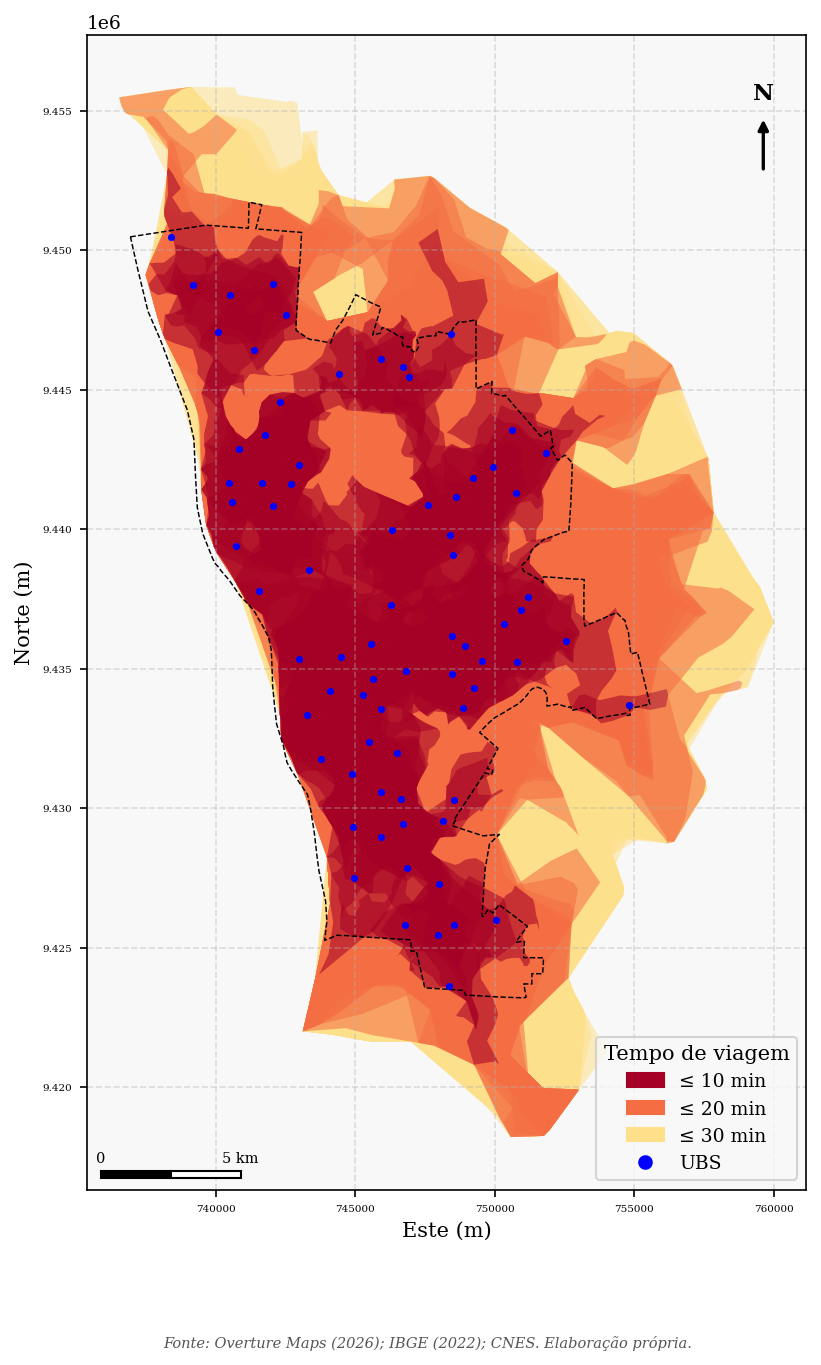

In [7]:
mapa_isocronas(isocronas_carro, "Overture Maps (2026); IBGE (2022); CNES. Elaboração própria.",
               "nb041_fig01_isocronas_carro.png")

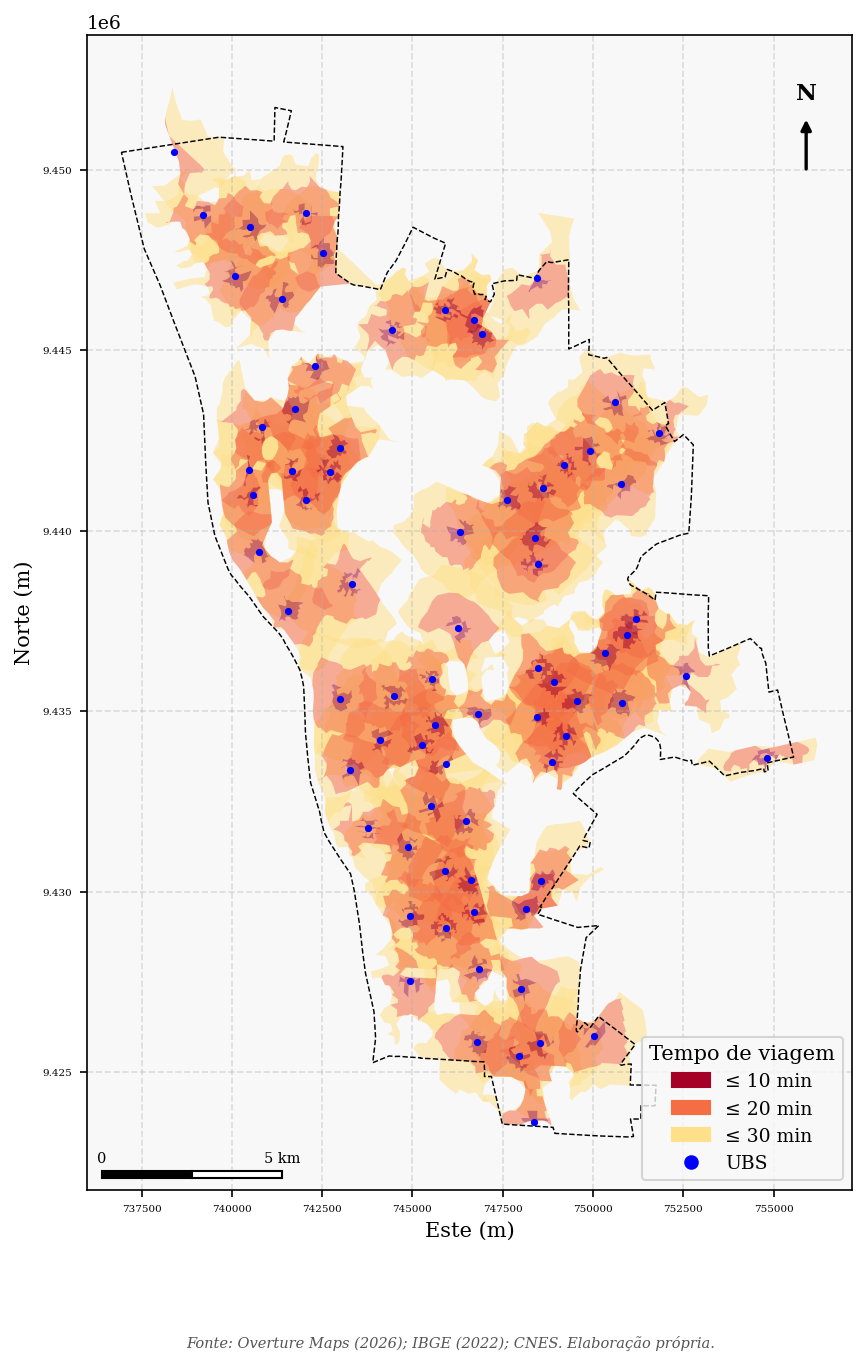

In [8]:
# ── Fig. 02 — Isócronas de pedestre (todas as UBS) ──────────────────────────
mapa_isocronas(isocronas_pe, "Overture Maps (2026); IBGE (2022); CNES. Elaboração própria.",
               "nb041_fig02_isocronas_pedestre.png")

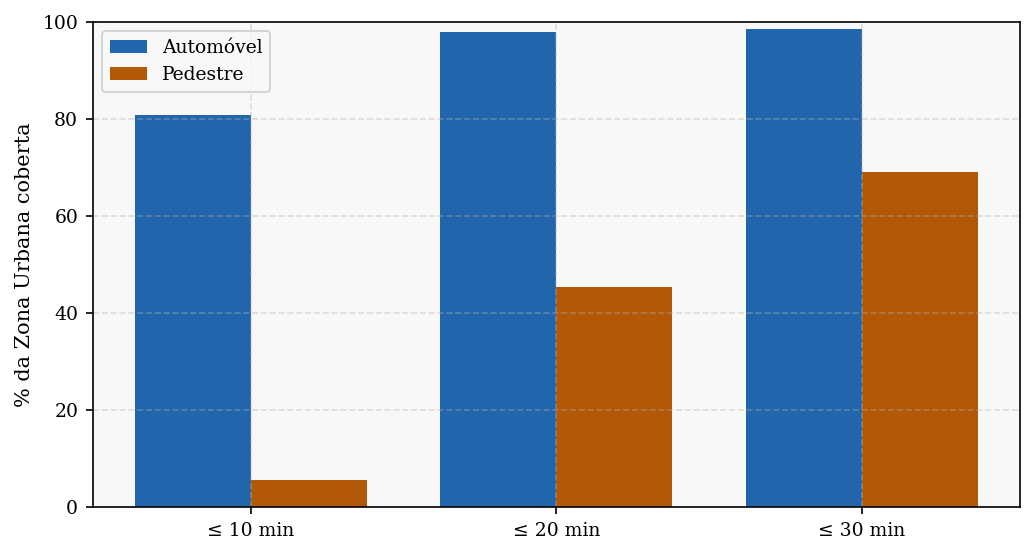

In [9]:
# ── Fig. 03 — Cobertura da Zona Urbana por tempo de viagem ──────────────────
# Área da ZU alcançável (cumulativa) por limiar, em cada modo.
area_zu = zona_urbana.area.sum()
def cobertura(iso):
    out = {}
    for limiar in LIMIARES_NOMINAIS:
        uniao = iso[iso["threshold_nominal"] <= limiar].union_all()
        out[limiar] = gpd.GeoSeries([uniao], crs=CRS_METRICO).clip(zona_urbana).area.sum() / area_zu * 100
    return out

cob_carro, cob_pe = cobertura(isocronas_carro), cobertura(isocronas_pe)
x = np.arange(len(LIMIARES_NOMINAIS)); w = 0.38
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.bar(x - w/2, [cob_carro[l] for l in LIMIARES_NOMINAIS], w, label="Automóvel", color="#2166AC")
ax.bar(x + w/2, [cob_pe[l] for l in LIMIARES_NOMINAIS], w, label="Pedestre", color="#B35806")
ax.set_xticks(x); ax.set_xticklabels([f"≤ {l} min" for l in LIMIARES_NOMINAIS])
ax.set_ylabel("% da Zona Urbana coberta"); ax.set_ylim(0, 100); ax.legend()
plt.tight_layout()
plt.savefig(FIGURAS_NB / "nb041_fig03_cobertura.png", bbox_inches="tight")
plt.show()

---
## Próximos passos
O **NB 05** cruzará estes anéis com a população (areal) dos setores censitários, aplicando
os pesos de decaimento do AE2SFCA (1,00 / 0,68 / 0,22) para calcular o índice de
acessibilidade e identificar os "desertos de saúde".